In [52]:
# Библиотеки
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

# Увеличим ширину столбцов, чтобы они не обрезались
pd.set_option('display.max_colwidth', None)

## Шаг1. Проверим данные

In [53]:
# Шаг 1.Проверим файл с таблицами 

RANDOM_STATE = 20326

url = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'
db_path = Path('ds-plus-final.db')

urlretrieve(url, db_path)

engine = create_engine(f'sqlite:///{db_path}', echo=False)

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
""", engine)

contract = pd.read_sql('SELECT * FROM contract', engine)
personal = pd.read_sql('SELECT * FROM personal', engine)
internet = pd.read_sql('SELECT * FROM internet', engine)
phone = pd.read_sql('SELECT * FROM phone', engine)

print("Список таблиц:")
display(tables)
print("Первые строки таблицы contract:")
display(contract.head())
print("Первые строки таблицы personal:")
display(personal.head())
print("Первые строки таблицы internet:")
display(internet.head())
print("Первые строки таблицы phone:")
display(phone.head()) 

Список таблиц:


,name
0,contract
1,data_arc
2,data_bulk
3,data_bulk_time
4,data_gas
5,data_temp
6,data_wire
7,data_wire_time
8,internet
9,personal


Первые строки таблицы contract:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


Первые строки таблицы personal:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Первые строки таблицы internet:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Первые строки таблицы phone:


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


### Вывод
Датасет содержит набор таблиц, необходимые таблицы на месте, данные в них присутсвуют, исследуем эти даные

## Шаг 2. Проведем иследовательский анализ данных и предобработку
### EDA

In [54]:
# Класс для EDA

class TelecomEDA:
    # Инициализация класса
    def __init__(self, engine, report_date='2020-02-01'):
        self.engine = engine
        self.report_date = pd.Timestamp(report_date)
        self.required_tables = ['contract', 'personal', 'internet', 'phone']
        self.tables = {}
        self.data = None

        self.base_exclude = ['customerID', 'BeginDate', 'EndDate']
        self.model_exclude = self.base_exclude + ['target']

        self.col_names = {
            'customerID': 'ID клиента',
            'BeginDate': 'Дата начала договора',
            'EndDate': 'Дата окончания договора',
            'Type': 'Тип оплаты',
            'PaperlessBilling': 'Электронный чек',
            'PaymentMethod': 'Способ оплаты',
            'MonthlyCharges': 'Ежемесячные расходы',
            'TotalCharges': 'Общие расходы',
            'gender': 'Пол',
            'SeniorCitizen': 'Пенсионер',
            'Partner': 'Наличие супруга',
            'Dependents': 'Наличие детей',
            'InternetService': 'Тип интернета',
            'OnlineSecurity': 'Блокировка опасных сайтов',
            'OnlineBackup': 'Облачное хранилище',
            'DeviceProtection': 'Антивирус',
            'TechSupport': 'Техподдержка',
            'StreamingTV': 'Стриминговое ТВ',
            'StreamingMovies': 'Каталог фильмов',
            'MultipleLines': 'Несколько телефонных линий',
            'contract_months': 'Длительность контракта в месяцах',
            'target': 'Отток'
        }

    # Метод для преобразования названий столбцов
    def _label(self, col):
        return self.col_names.get(col, col)

    # Метод для получения списка колонок
    def _cols(self, df, exclude):
        return [col for col in df.columns if col not in exclude]

    # Метод для загрузки таблиц
    def load_tables(self):
        all_tables = pd.read_sql("""
            SELECT name
            FROM sqlite_master
            WHERE type = 'table'
            ORDER BY name
        """, self.engine)

        self.all_table_names = all_tables['name'].tolist()

        missing_tables = [t for t in self.required_tables if t not in self.all_table_names]
        if missing_tables:
            raise ValueError(f'Нет нужных таблиц: {missing_tables}')

        for table_name in self.required_tables:
            self.tables[table_name] = pd.read_sql(f'SELECT * FROM {table_name}', self.engine)

        if 'CustomerId' in self.tables['phone'].columns:
            self.tables['phone'] = self.tables['phone'].rename(columns={'CustomerId': 'customerID'})

        self.tables['contract']['MonthlyCharges'] = pd.to_numeric(
            self.tables['contract']['MonthlyCharges'], errors='coerce'
        )
        self.tables['contract']['TotalCharges'] = pd.to_numeric(
            self.tables['contract']['TotalCharges'], errors='coerce'
        )

        empty_tables = [name for name, df in self.tables.items() if df.empty]
        if empty_tables:
            raise ValueError(f'Пустые таблицы: {empty_tables}')

    # Метод для проверки таблиц
    def check_tables(self):
        print(f'Всего таблиц в базе: {len(self.all_table_names)}')
        print(f'Нужные таблицы для проекта: {", ".join(self.required_tables)}')

        extra_tables = [t for t in self.all_table_names if t not in self.required_tables]
        if extra_tables:
            print(f'Дополнительные таблицы, которые не используются: {", ".join(extra_tables)}')

        summary = pd.DataFrame({
            'Таблица': self.required_tables,
            'Строк': [len(self.tables[t]) for t in self.required_tables],
            'Столбцов': [self.tables[t].shape[1] for t in self.required_tables]
        })
        display(summary)

    # Метод для отображения информации о таблице
    def show_table_info(self, table_name, max_unique=10):
        df = self.tables[table_name].copy()

        print(f'\nТаблица {table_name}')
        print('Размер:', df.shape)

        missing = df.isna().sum().reset_index()
        missing.columns = ['Признак', 'Пропуски']
        display(missing)

        small_cardinality = []
        for col in self._cols(df, ['customerID']):
            unique_count = df[col].nunique(dropna=False)
            if unique_count <= max_unique:
                values = sorted(df[col].astype(str).fillna('NaN').unique().tolist())
                small_cardinality.append({
                    'Признак': col,
                    'Уникальных значений': unique_count,
                    'Значения': ', '.join(values)
                })

        if small_cardinality:
            display(pd.DataFrame(small_cardinality))

        numeric_cols = df.select_dtypes(include='number').columns.tolist()
        if numeric_cols:
            display(df[numeric_cols].describe().T)

        plot_cols = self._cols(df, self.base_exclude)
        self._plot_distributions(df, plot_cols, f'Распределение признаков таблицы {table_name}')

    # Метод для построения распределений признаков
    def _plot_distributions(self, df, columns, main_title):
        ncols = 3
        nrows = math.ceil(len(columns) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.5 * nrows))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, columns):
            series = df[col]

            if pd.api.types.is_numeric_dtype(series) and series.nunique(dropna=False) > 10:
                ax.hist(series.dropna(), bins=30)
                ax.set_xlabel(self._label(col))
                ax.set_ylabel('Количество')
                ax.set_title(f'Распределение: {self._label(col)}')

                if col == 'MonthlyCharges':
                    ax.set_xticks(np.linspace(series.min(), series.max(), 5))
            else:
                counts = series.fillna('Пропуск').astype(str).value_counts()
                sns.barplot(x=counts.index, y=counts.values, ax=ax)
                ax.set_xlabel(self._label(col))
                ax.set_ylabel('Количество')
                ax.set_title(f'Распределение: {self._label(col)}')
                ax.tick_params(axis='x', rotation=45)

        for ax in axes[len(columns):]:
            ax.axis('off')

        plt.suptitle(main_title, fontsize=16)
        plt.tight_layout()
        plt.show()

    # Метод для объединения и подготовки данных
    def merge_and_prepare(self):
        contract = self.tables['contract'].copy()
        personal = self.tables['personal'].copy()
        internet = self.tables['internet'].copy()
        phone = self.tables['phone'].copy()

        df = (
            contract
            .merge(personal, on='customerID', how='left')
            .merge(internet, on='customerID', how='left')
            .merge(phone, on='customerID', how='left')
        )

        internet_cols = [
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]
        df[internet_cols] = df[internet_cols].fillna('No internet service')
        df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

        df['BeginDate'] = pd.to_datetime(df['BeginDate'])
        df['target'] = (df['EndDate'] != 'No').astype(int)

        end_date_for_calc = pd.to_datetime(
            df['EndDate'].replace('No', self.report_date.strftime('%Y-%m-%d'))
        )

        df['contract_months'] = (
            (end_date_for_calc.dt.year - df['BeginDate'].dt.year) * 12
            + (end_date_for_calc.dt.month - df['BeginDate'].dt.month)
        ).clip(lower=0)

        missing_total = df['TotalCharges'].isna()
        df.loc[missing_total, 'TotalCharges'] = (
            df.loc[missing_total, 'MonthlyCharges'].astype(float)
            * df.loc[missing_total, 'contract_months'].astype(float)
        )

        self.data = df

    # Метод для отображения информации о объединённой таблице
    def show_merged_info(self, max_unique=10):
        print('\nОбъединённая таблица')
        print('Размер:', self.data.shape)

        missing = self.data.isna().sum().reset_index()
        missing.columns = ['Признак', 'Пропуски']
        display(missing)

        small_cardinality = []
        for col in self._cols(self.data, self.base_exclude):
            unique_count = self.data[col].nunique(dropna=False)
            if unique_count <= max_unique:
                values = sorted(self.data[col].astype(str).fillna('NaN').unique().tolist())
                small_cardinality.append({
                    'Признак': col,
                    'Уникальных значений': unique_count,
                    'Значения': ', '.join(values)
                })

        if small_cardinality:
            display(pd.DataFrame(small_cardinality))

        plot_cols = self._cols(self.data, self.base_exclude)
        print('Распределение признаков объединённой таблицы')
        self._plot_distributions(self.data, plot_cols, ' ')

    # Метод для построения графика оттока по признакам
    def plot_target_by_feature(self):
        df = self.data.copy()
        plot_cols = self._cols(df, self.model_exclude)

        ncols = 3
        nrows = math.ceil(len(plot_cols) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.8 * nrows))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, plot_cols):
            if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique(dropna=False) > 10:
                sns.boxplot(data=df, x='target', y=col, ax=ax)
                ax.set_xlabel('Отток')
                ax.set_ylabel(self._label(col))
                ax.set_title(f'{self._label(col)} и отток')
                ax.set_xticklabels(['Остался', 'Ушёл'])
            else:
                sns.countplot(data=df, x=col, hue='target', ax=ax)
                ax.set_xlabel(self._label(col))
                ax.set_ylabel('Количество')
                ax.set_title(f'{self._label(col)} и отток')
                ax.tick_params(axis='x', rotation=45)
                ax.legend(title='Отток', labels=['Остался', 'Ушёл'])

        for ax in axes[len(plot_cols):]:
            ax.axis('off')

        print('Соотношение ушедших и оставшихся клиентов по признакам')
        plt.tight_layout()
        plt.show()

    # Метод для построения корреляционной матрицы признаков
    def plot_correlation(self):
        corr_df = self.data.drop(columns=self.base_exclude).copy()
        corr_df = pd.get_dummies(corr_df, drop_first=False)
        corr = corr_df.corr()

        plt.figure(figsize=(22, 18))
        sns.heatmap(
            corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            square=True,
            annot_kws={'size': 8}
        )
        plt.title('Корреляционная матрица признаков', fontsize=16)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # Метод для запуска EDA
    def run(self):
        self.load_tables()
        self.check_tables()

        for table_name in self.required_tables:
            self.show_table_info(table_name)

        self.merge_and_prepare()
        self.show_merged_info()
        self.plot_target_by_feature()
        self.plot_correlation()

Всего таблиц в базе: 11
Нужные таблицы для проекта: contract, personal, internet, phone
Дополнительные таблицы, которые не используются: data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time


,Таблица,Строк,Столбцов
0,contract,7043,8
1,personal,7043,5
2,internet,5517,8
3,phone,6361,2



Таблица contract
Размер: (7043, 8)


,Признак,Пропуски
0,customerID,0
1,BeginDate,0
2,EndDate,0
3,Type,0
4,PaperlessBilling,0
5,PaymentMethod,0
6,MonthlyCharges,0
7,TotalCharges,11


,Признак,Уникальных значений,Значения
0,Type,3,"Month-to-month, One year, Two year"
1,PaperlessBilling,2,"No, Yes"
2,PaymentMethod,4,"Bank transfer (automatic), Credit card (automatic), Electronic check, Mailed check"


,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.8500,118.75
TotalCharges,7032.0,2118.621822,2112.736199,19.05,439.745,1345.275,3239.3175,9221.38


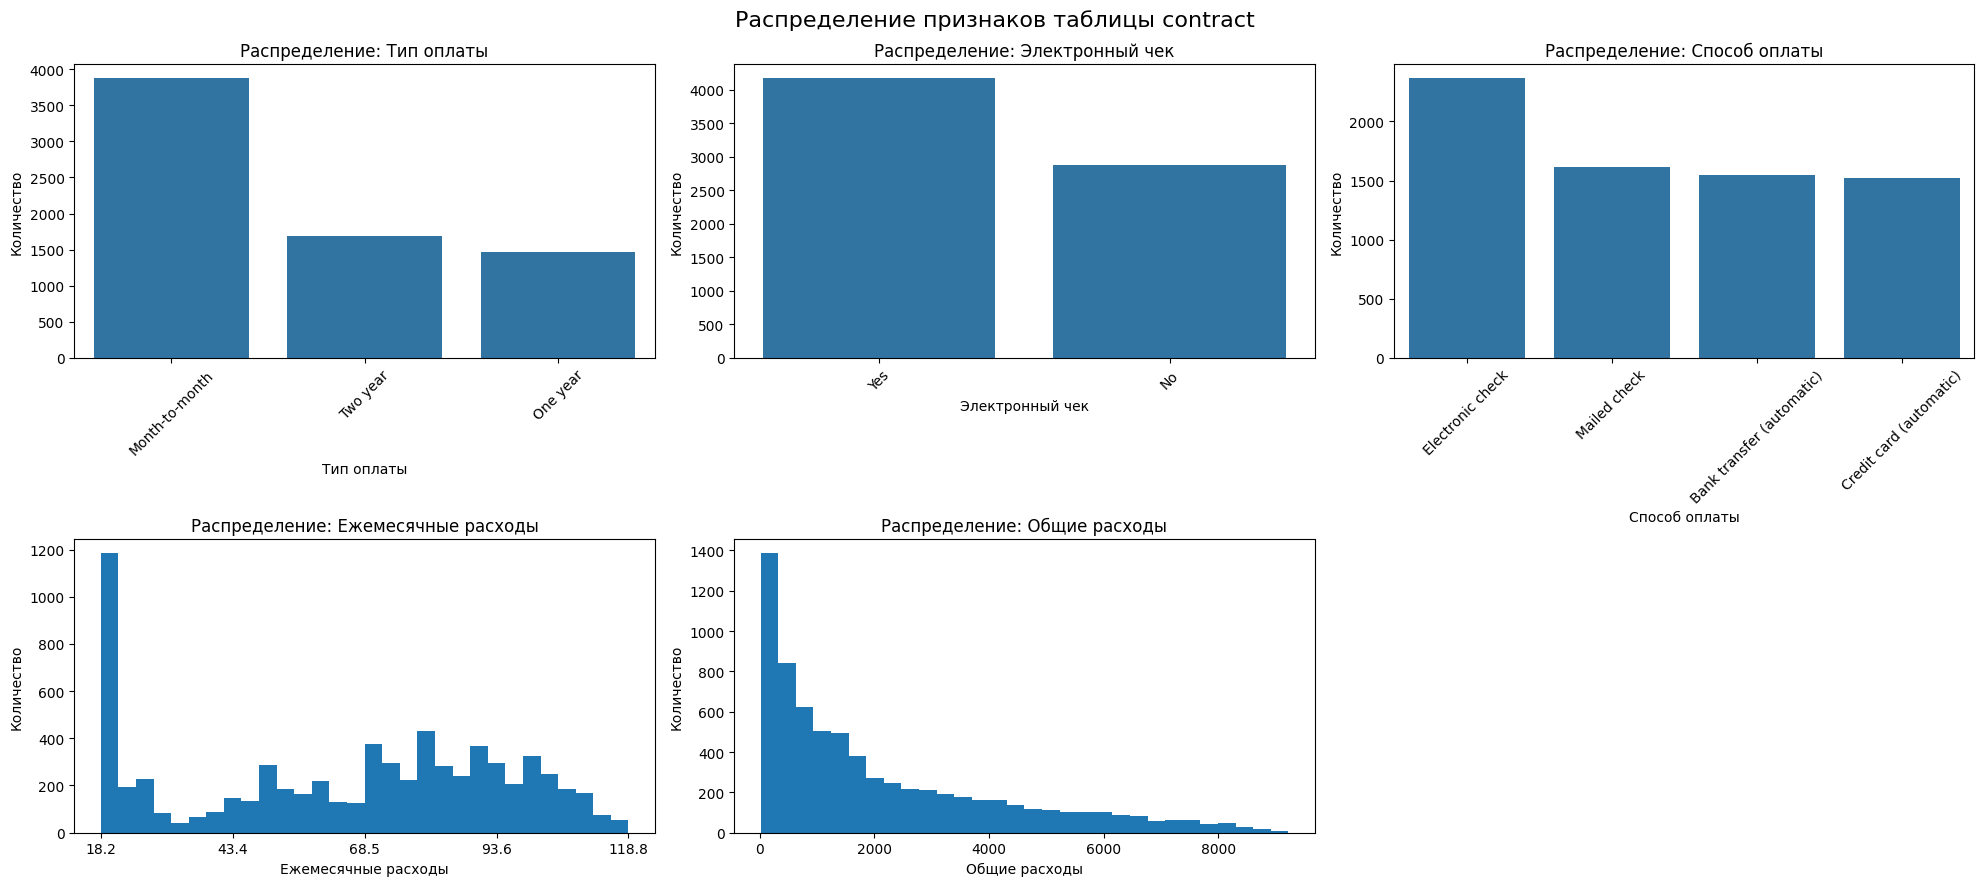


Таблица personal
Размер: (7043, 5)


,Признак,Пропуски
0,customerID,0
1,gender,0
2,SeniorCitizen,0
3,Partner,0
4,Dependents,0


,Признак,Уникальных значений,Значения
0,gender,2,"Female, Male"
1,SeniorCitizen,2,"0, 1"
2,Partner,2,"No, Yes"
3,Dependents,2,"No, Yes"


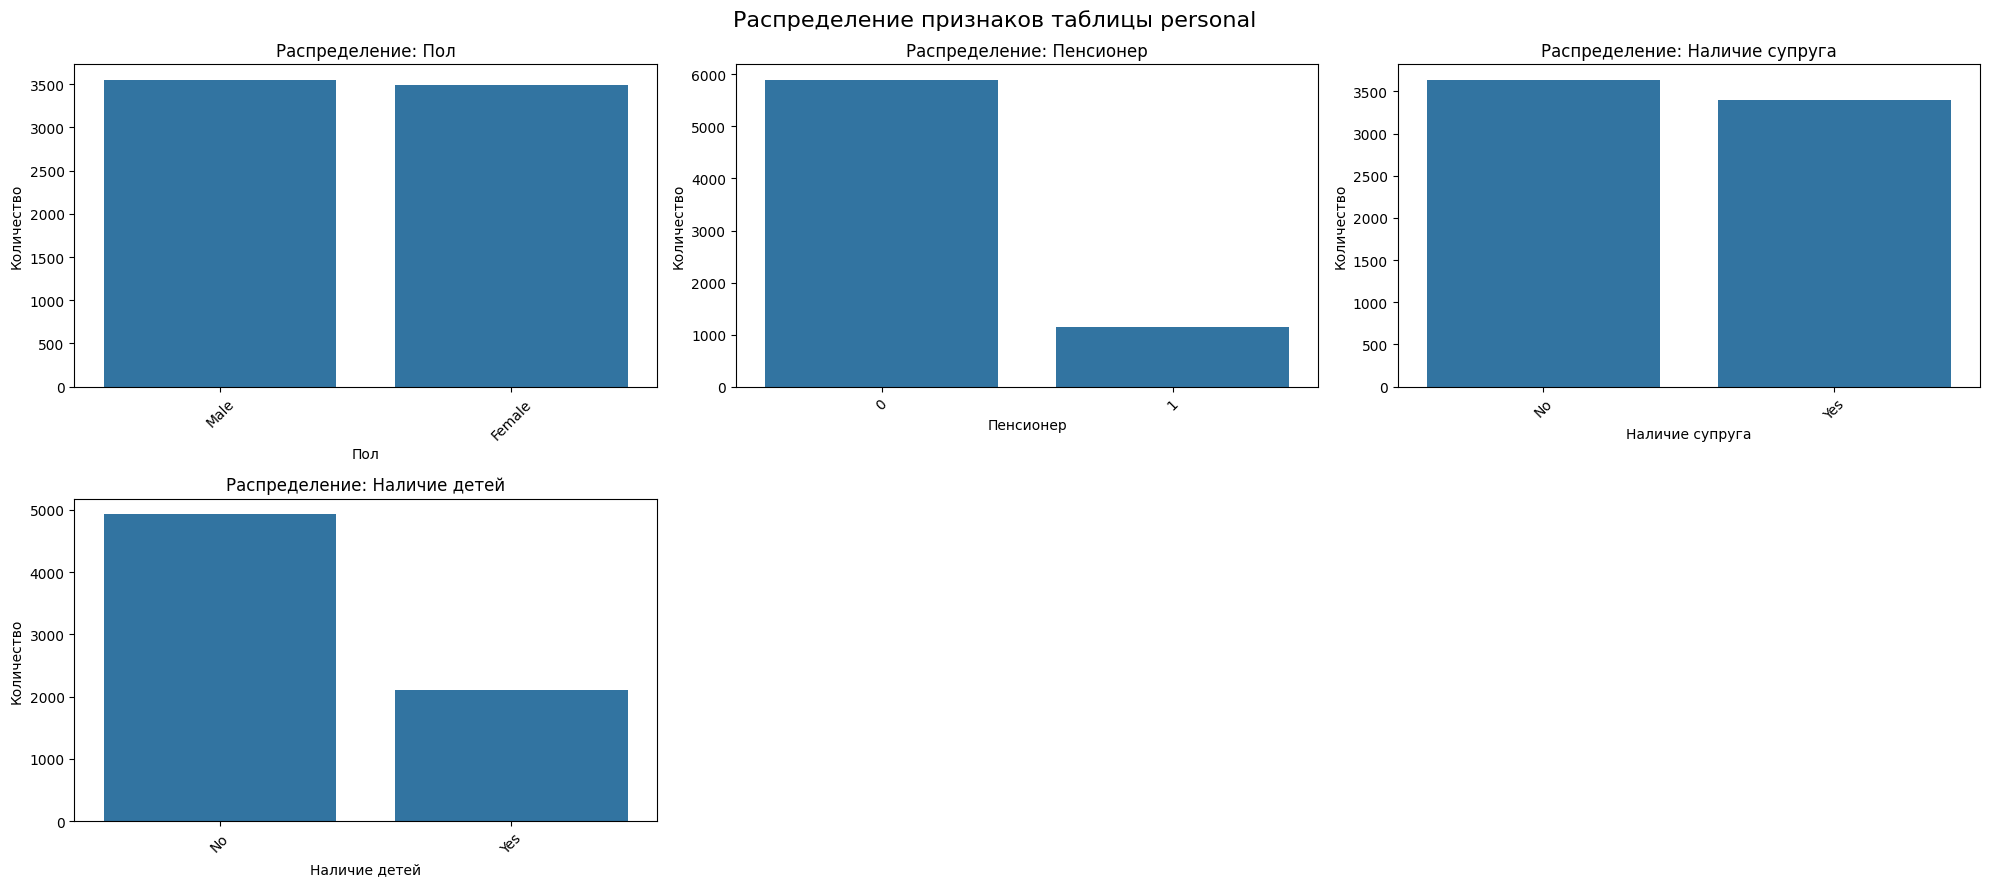


Таблица internet
Размер: (5517, 8)


,Признак,Пропуски
0,customerID,0
1,InternetService,0
2,OnlineSecurity,0
3,OnlineBackup,0
4,DeviceProtection,0
5,TechSupport,0
6,StreamingTV,0
7,StreamingMovies,0


,Признак,Уникальных значений,Значения
0,InternetService,2,"DSL, Fiber optic"
1,OnlineSecurity,2,"No, Yes"
2,OnlineBackup,2,"No, Yes"
3,DeviceProtection,2,"No, Yes"
4,TechSupport,2,"No, Yes"
5,StreamingTV,2,"No, Yes"
6,StreamingMovies,2,"No, Yes"


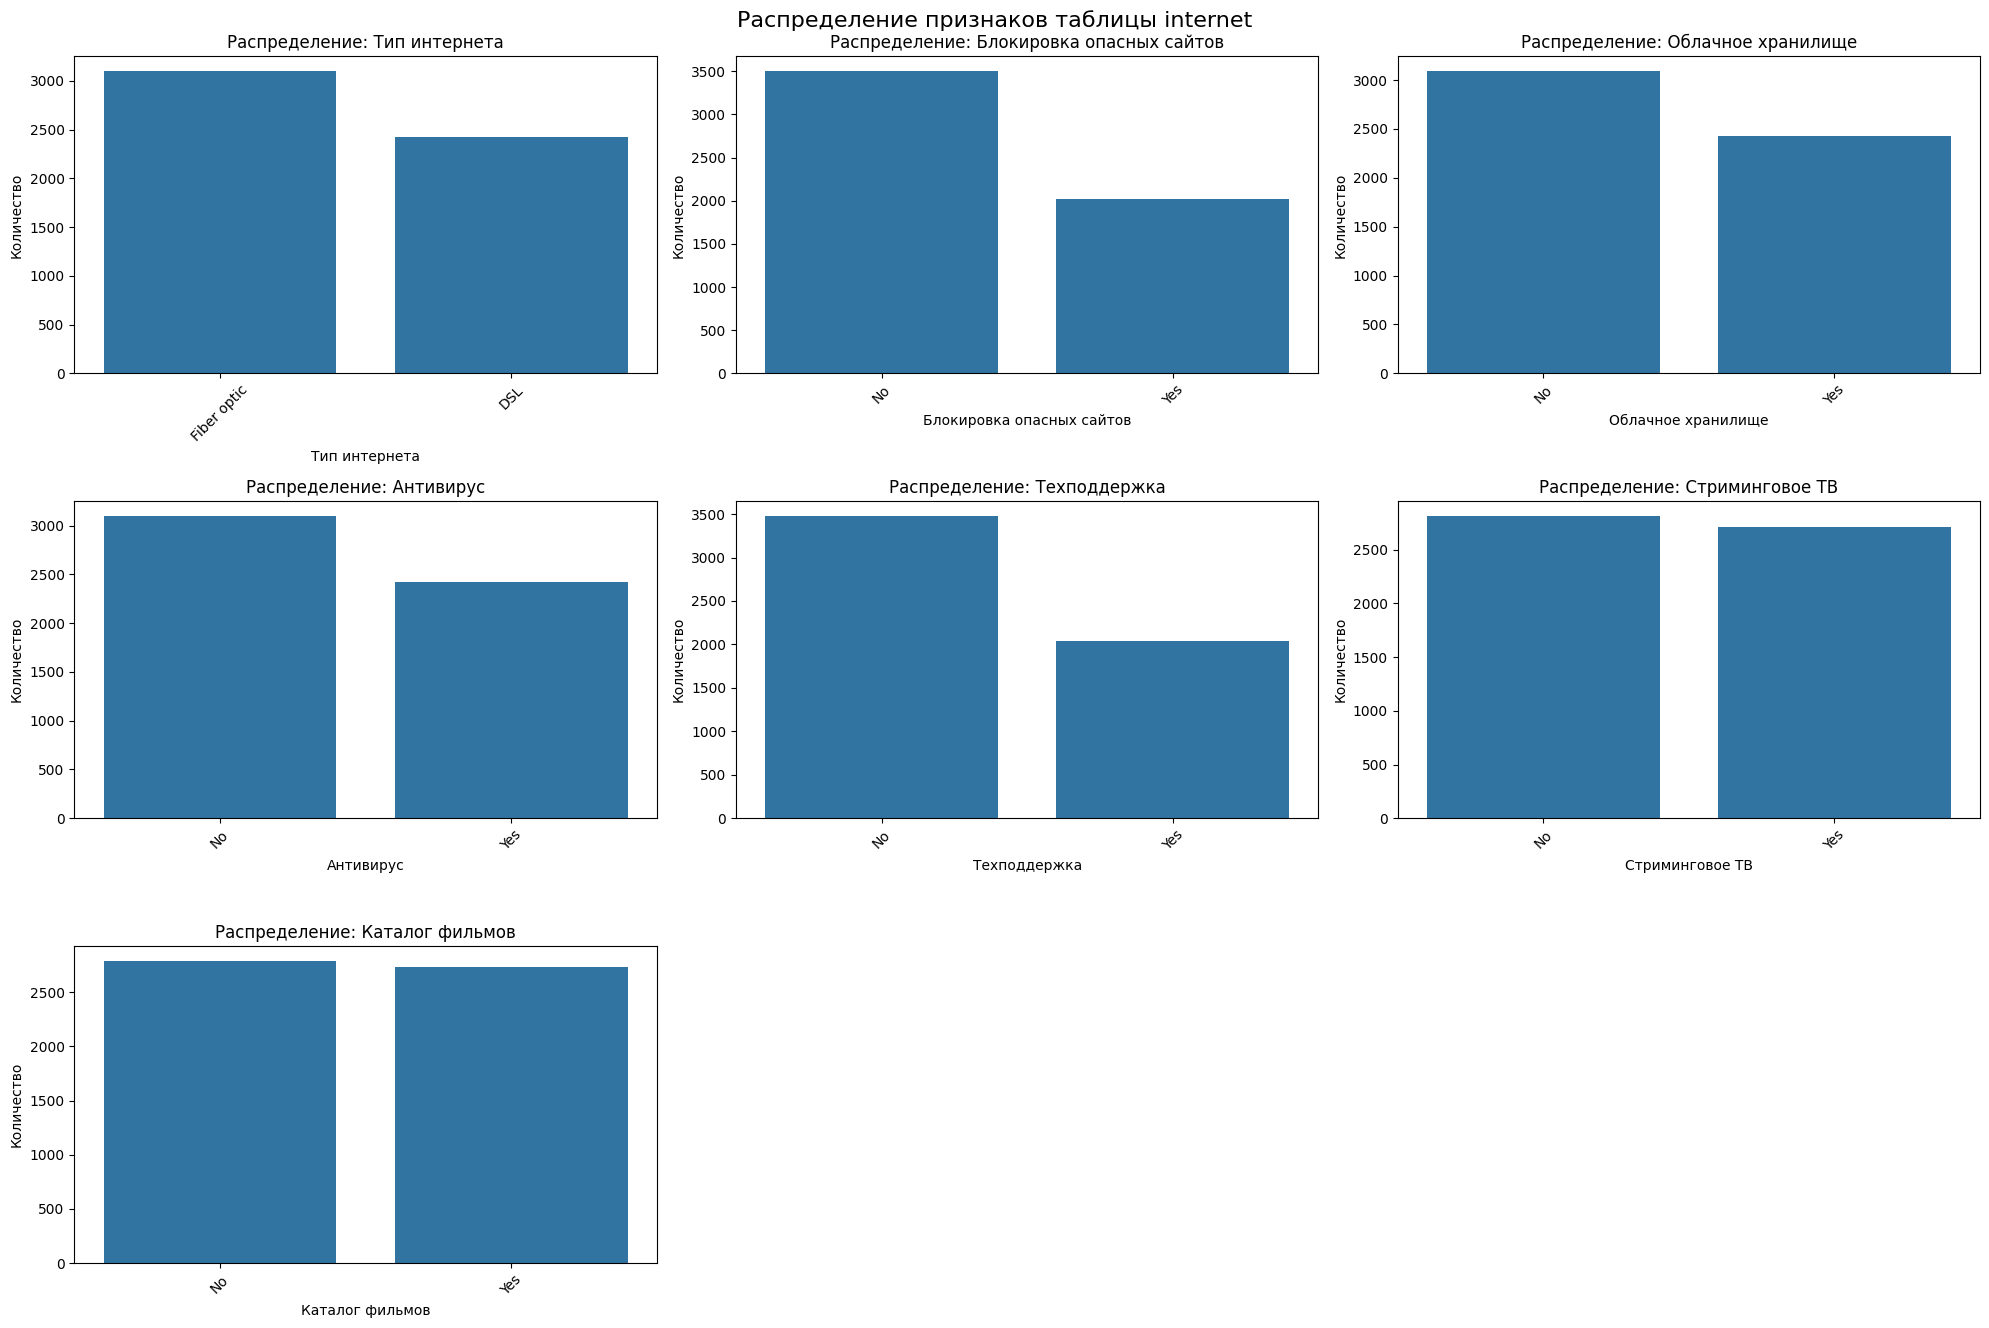


Таблица phone
Размер: (6361, 2)


,Признак,Пропуски
0,customerID,0
1,MultipleLines,0


,Признак,Уникальных значений,Значения
0,MultipleLines,2,"No, Yes"


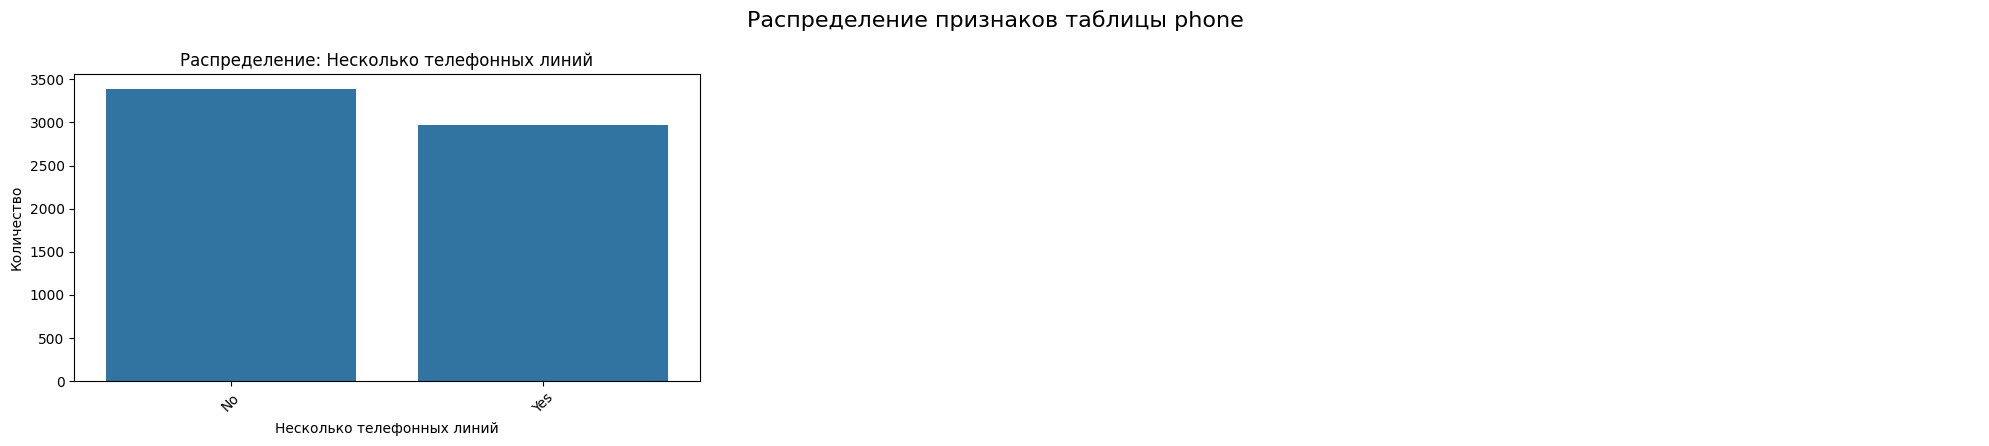


Объединённая таблица
Размер: (7043, 22)


,Признак,Пропуски
0,customerID,0
1,BeginDate,0
2,EndDate,0
3,Type,0
4,PaperlessBilling,0
5,PaymentMethod,0
6,MonthlyCharges,0
7,TotalCharges,0
8,gender,0
9,SeniorCitizen,0


,Признак,Уникальных значений,Значения
0,Type,3,"Month-to-month, One year, Two year"
1,PaperlessBilling,2,"No, Yes"
2,PaymentMethod,4,"Bank transfer (automatic), Credit card (automatic), Electronic check, Mailed check"
3,gender,2,"Female, Male"
4,SeniorCitizen,2,"0, 1"
5,Partner,2,"No, Yes"
6,Dependents,2,"No, Yes"
7,InternetService,3,"DSL, Fiber optic, No internet service"
8,OnlineSecurity,3,"No, No internet service, Yes"
9,OnlineBackup,3,"No, No internet service, Yes"


Распределение признаков объединённой таблицы


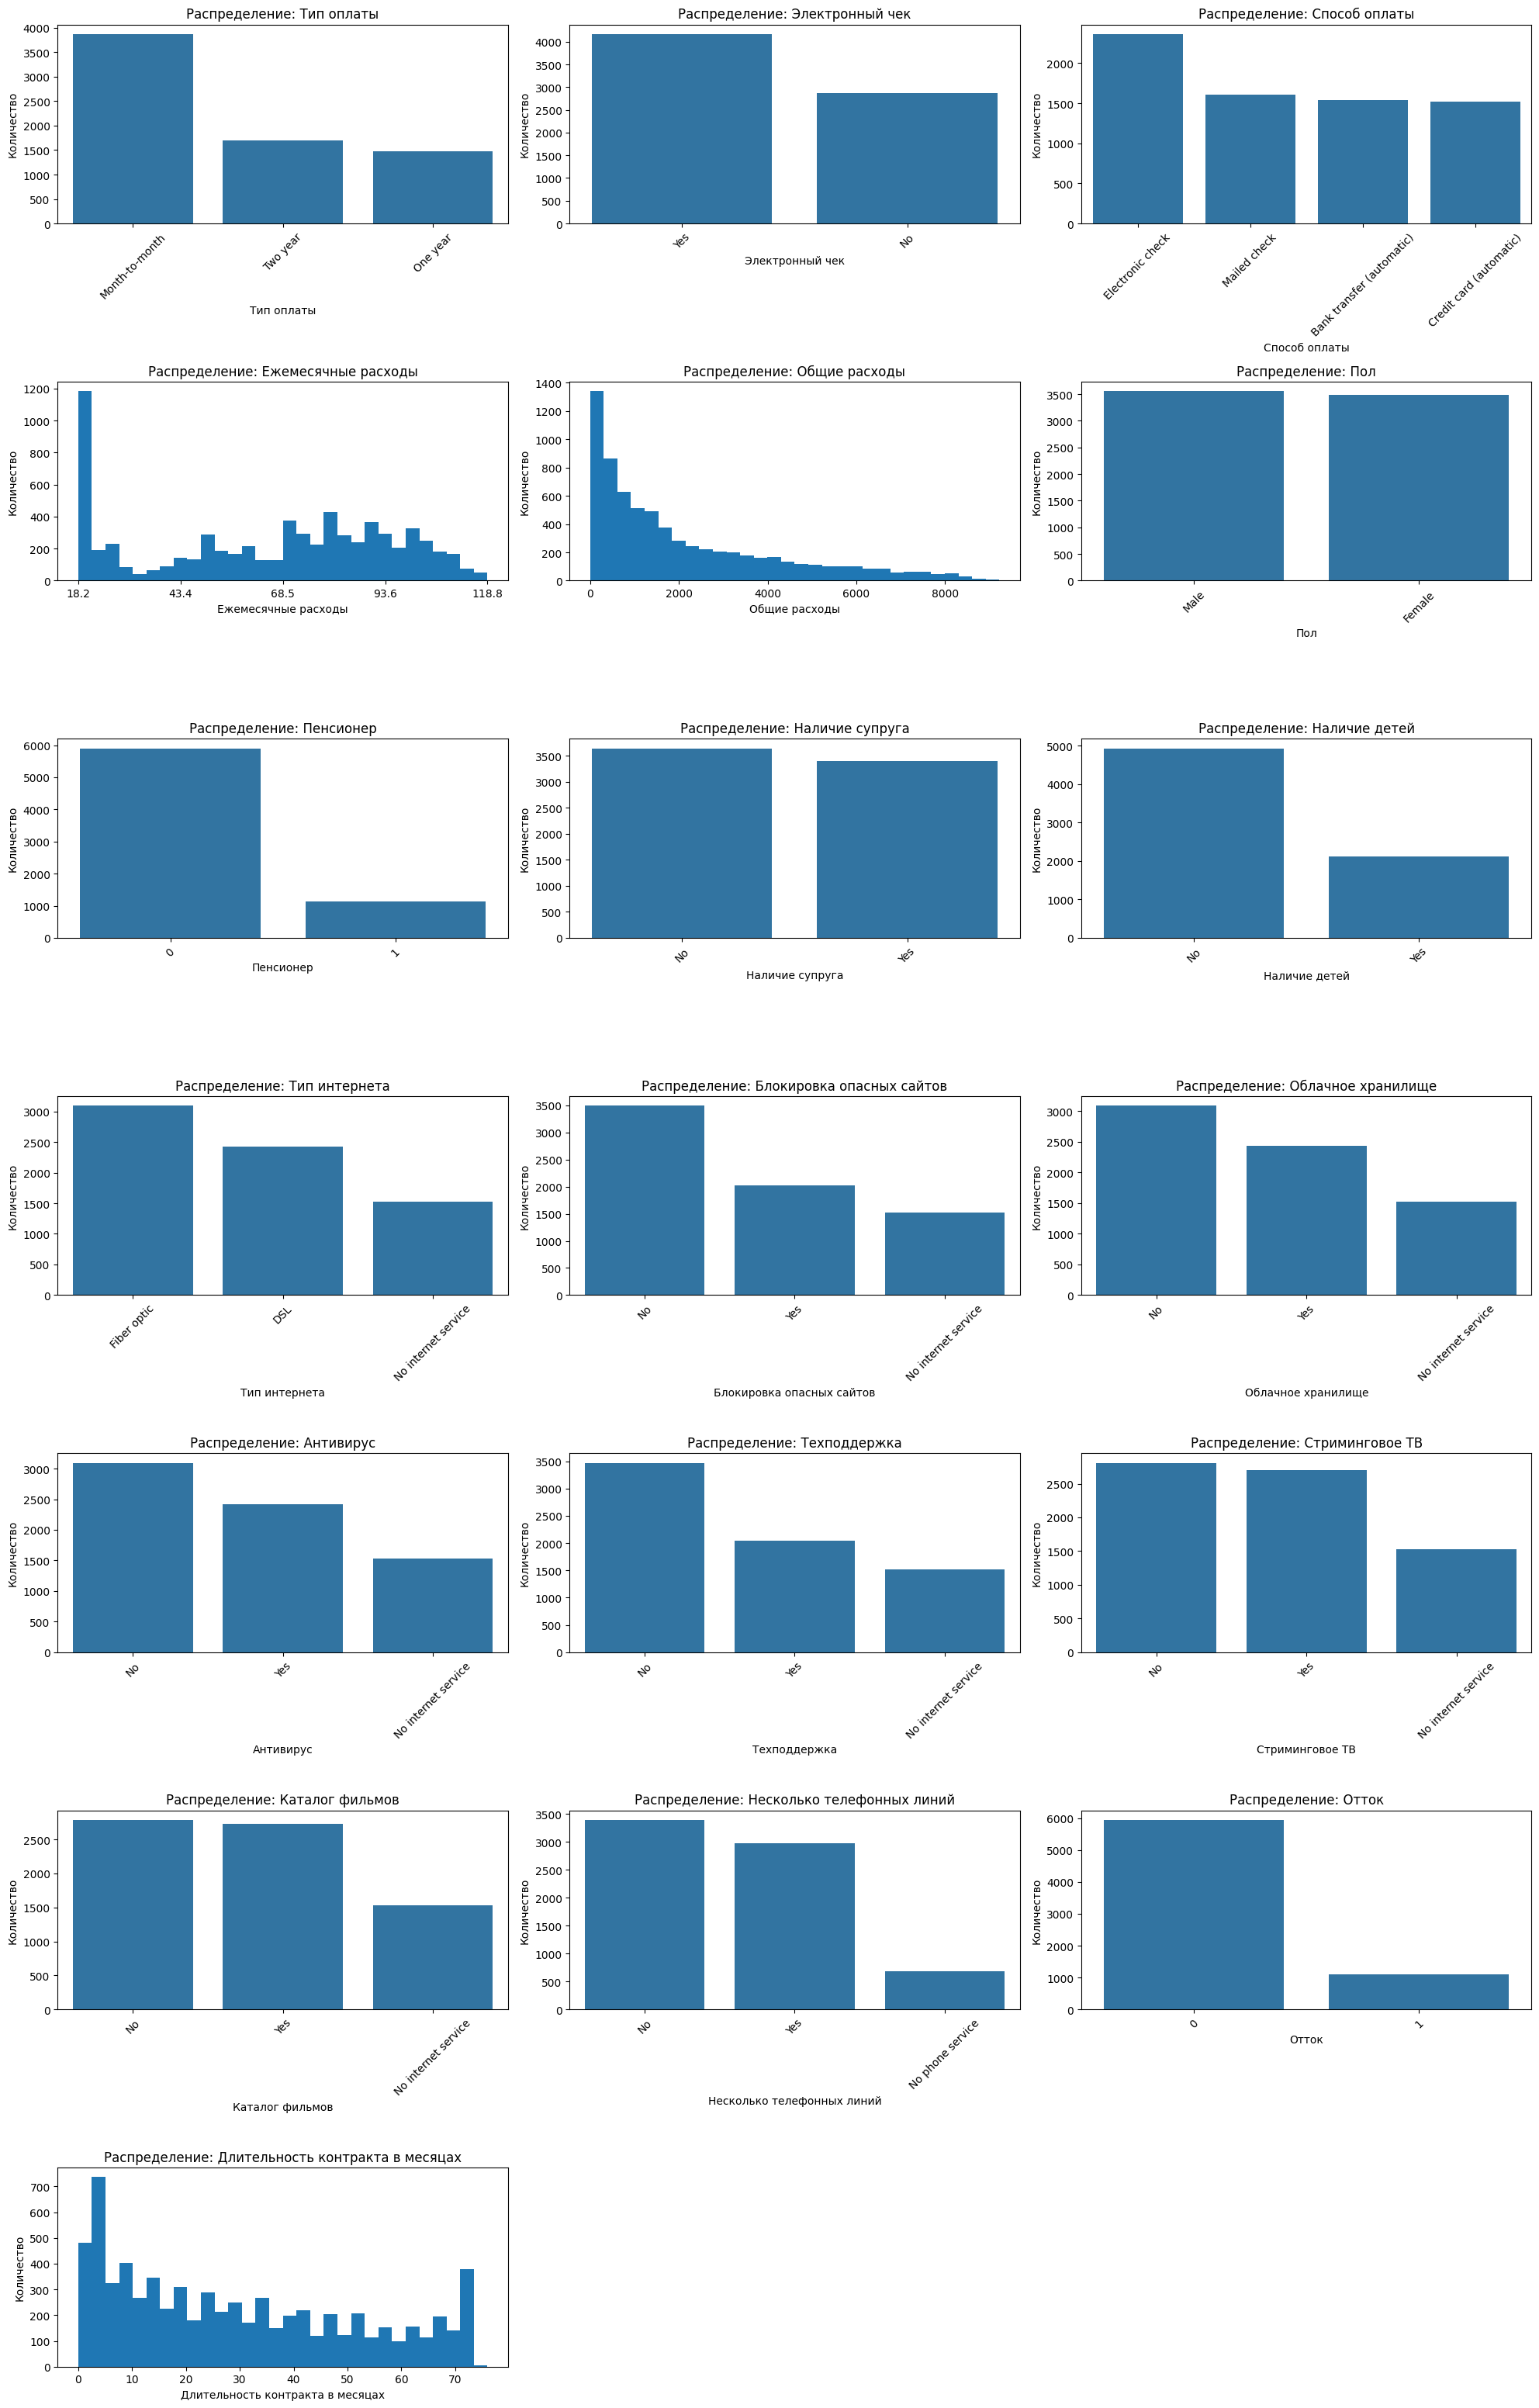

/tmp/ipykernel_12198/1529498785.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Остался', 'Ушёл'])
/tmp/ipykernel_12198/1529498785.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Остался', 'Ушёл'])
/tmp/ipykernel_12198/1529498785.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Остался', 'Ушёл'])


Соотношение ушедших и оставшихся клиентов по признакам


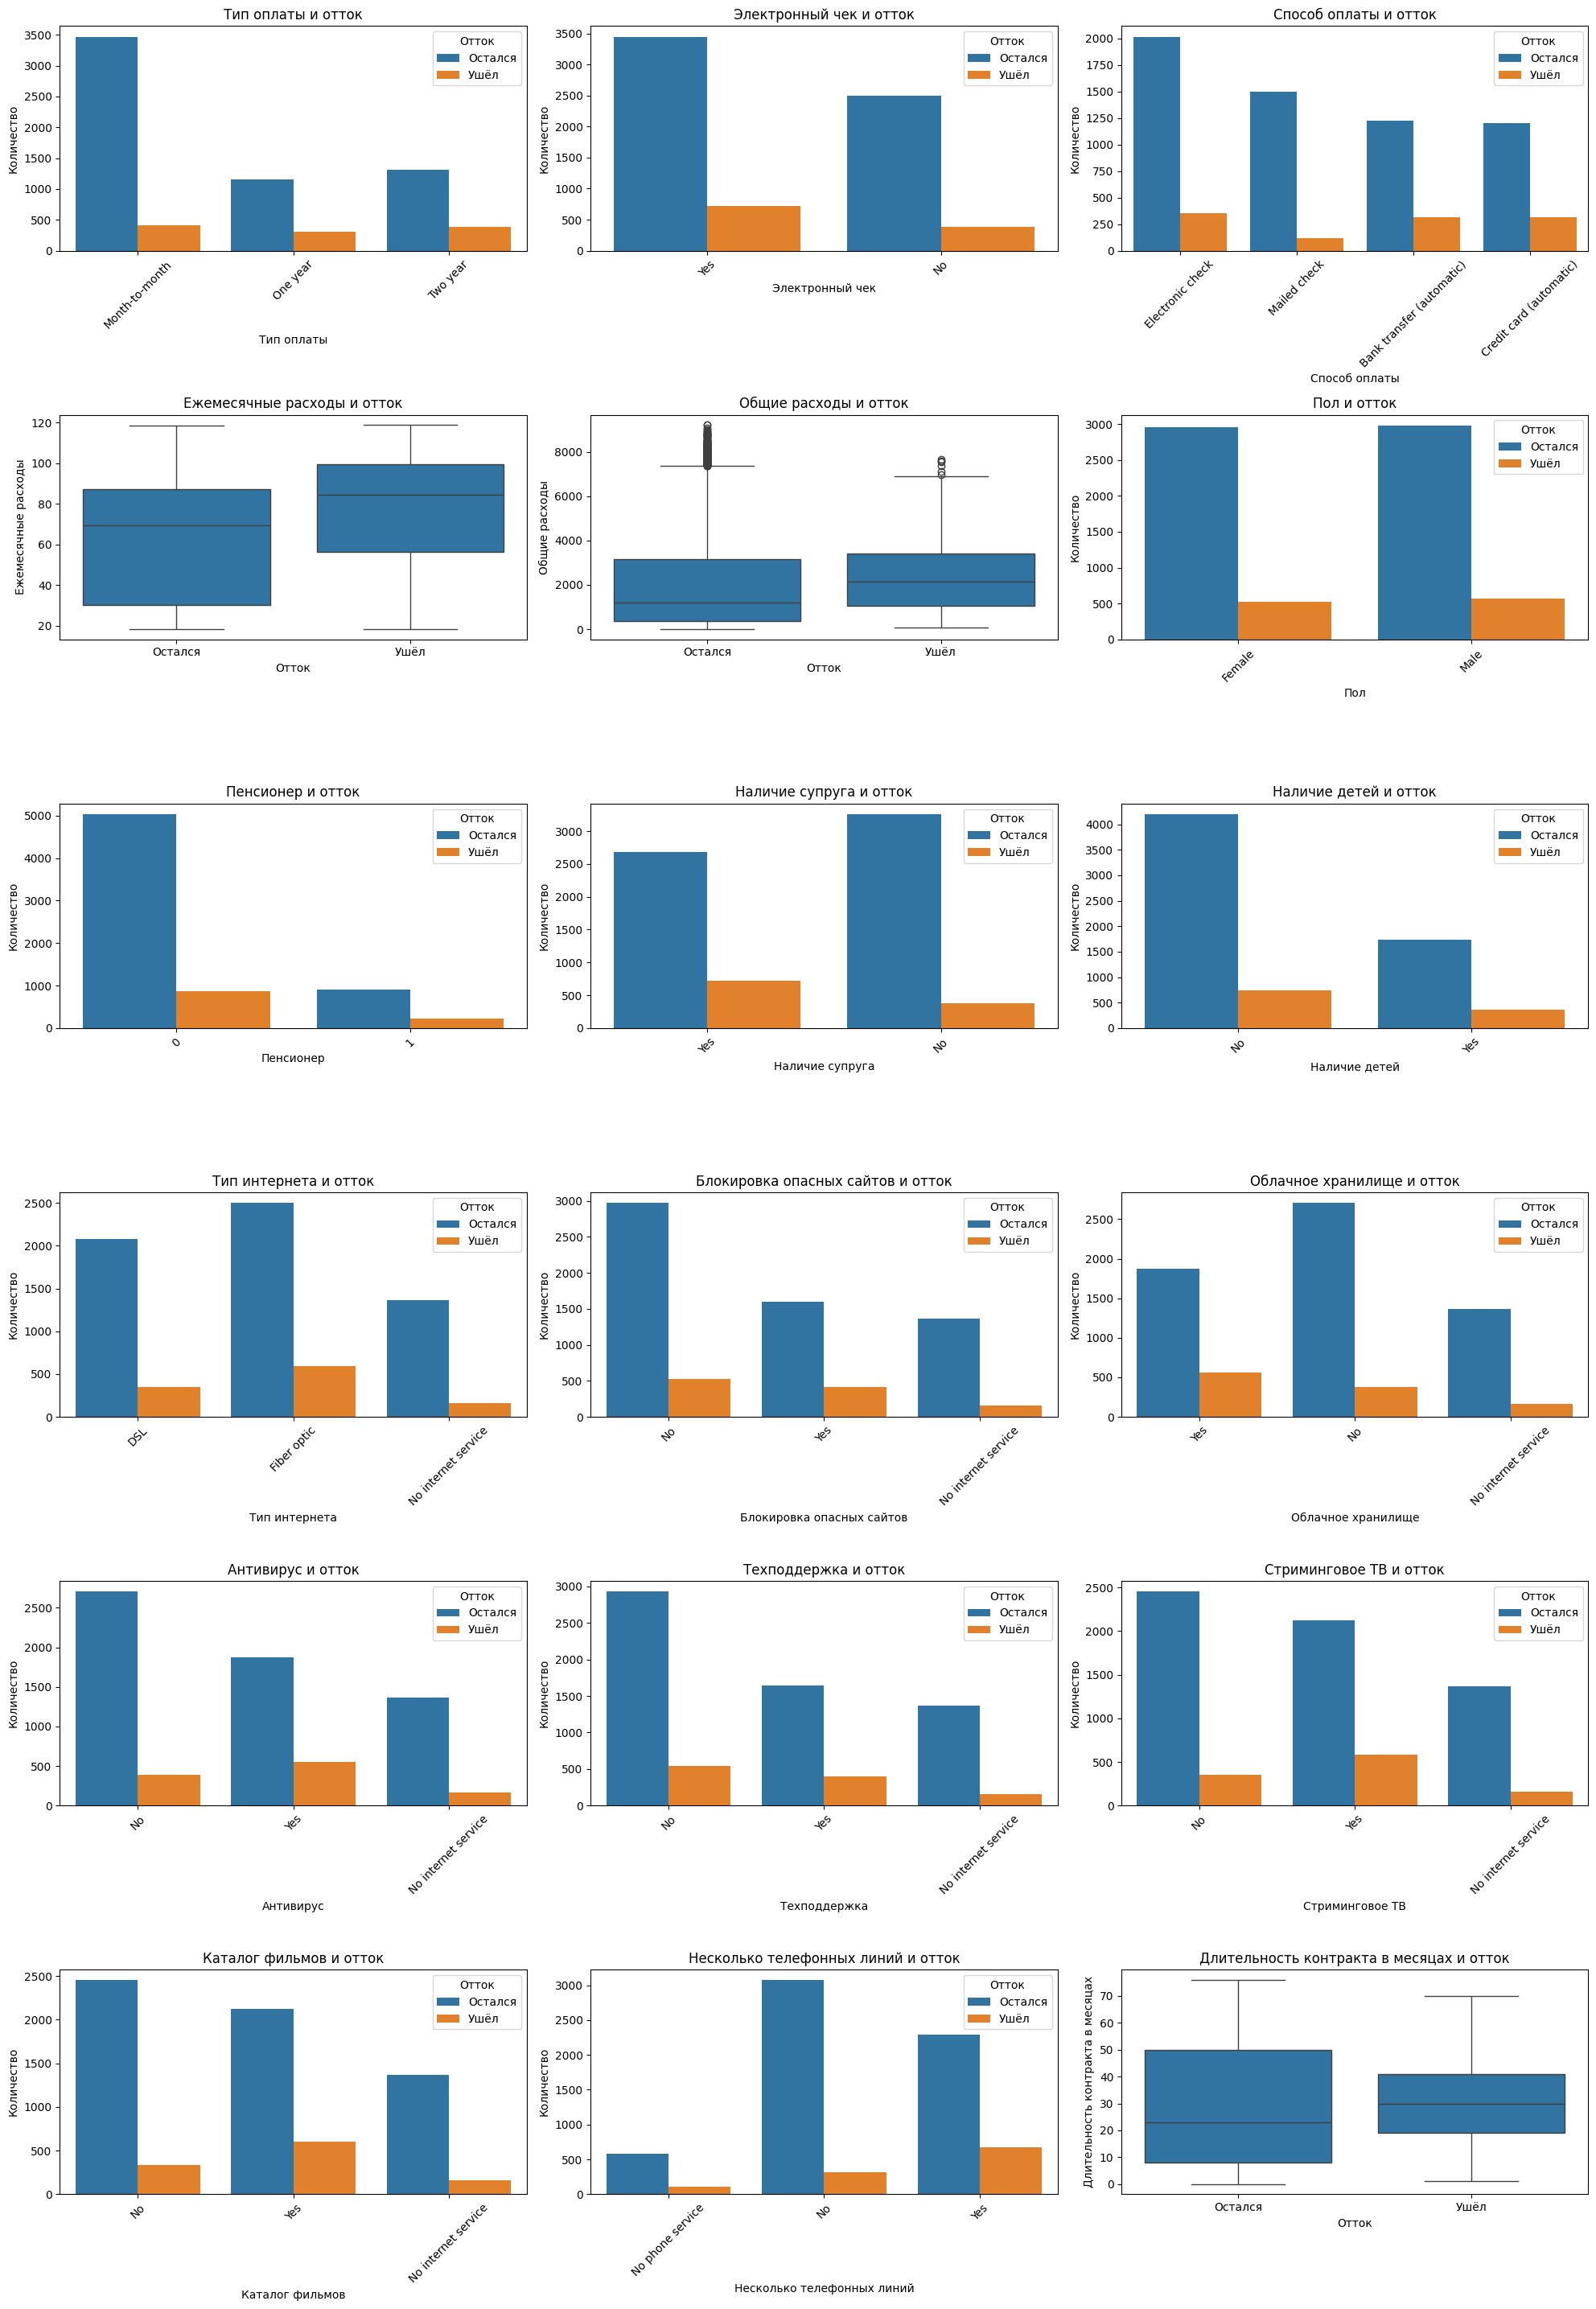

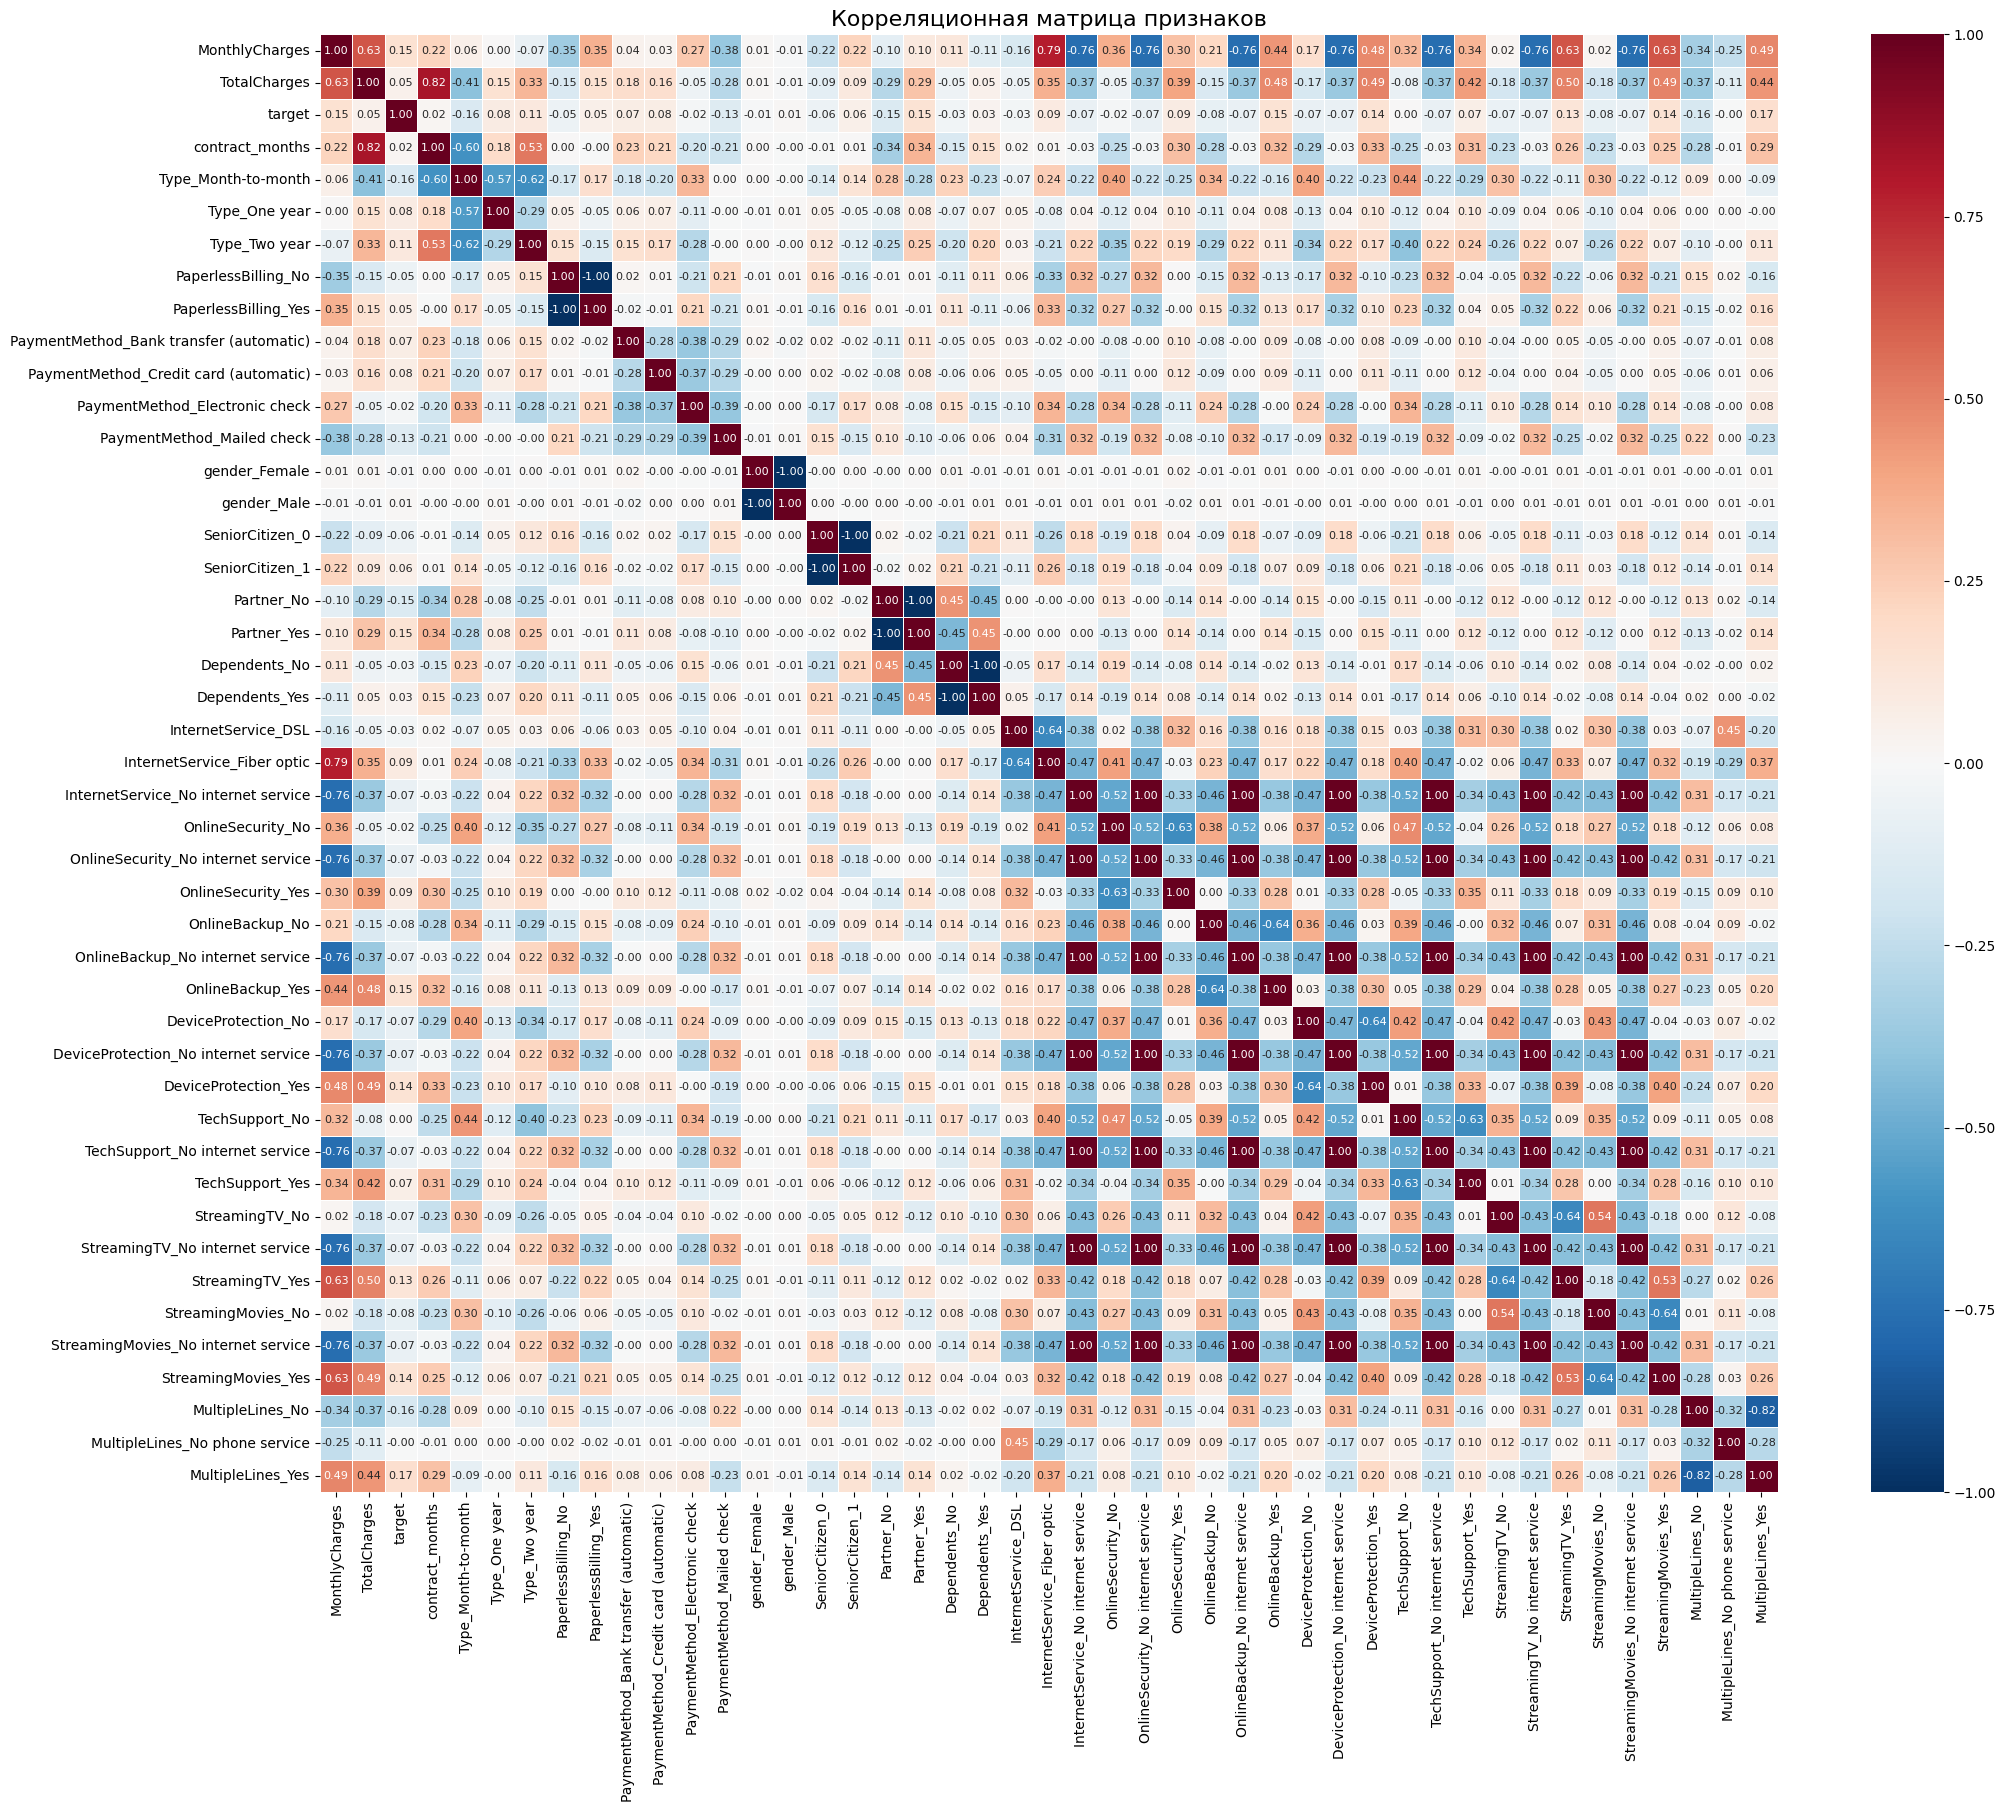

In [55]:
# Проведем EDA
eda = TelecomEDA(engine)
eda.run()

### Подготовка данных

In [56]:
# Класс для подготовки данных

class TelecomDataPrep:
    # Инициализация класса
    def __init__(self, data):
        self.data = data.copy()
        self.target_col = 'target'
        self.drop_cols = ['customerID', 'BeginDate', 'EndDate', 'target']

    def prepare(self):
        # Подготовка данных
        X = self.data.drop(columns=self.drop_cols)
        y = self.data[self.target_col]

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=RANDOM_STATE,
            stratify=y
        )

        categorical_cols = X_train_raw.select_dtypes(
            include=['object', 'string', 'category']
        ).columns.tolist()

        numeric_cols = X_train_raw.select_dtypes(
            exclude=['object', 'string', 'category']
        ).columns.tolist()

        X_train_cat = X_train_raw.copy()
        X_test_cat = X_test_raw.copy()

        for col in categorical_cols:
            X_train_cat[col] = X_train_cat[col].astype('category')
            X_test_cat[col] = X_test_cat[col].astype('category')

        cat_features = categorical_cols

        X_train_rf = pd.get_dummies(X_train_raw, drop_first=False)
        X_test_rf = pd.get_dummies(X_test_raw, drop_first=False)
        X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

        scaler = StandardScaler()
        X_train_mlp = X_train_rf.copy()
        X_test_mlp = X_test_rf.copy()

        X_train_mlp[numeric_cols] = scaler.fit_transform(X_train_mlp[numeric_cols])
        X_test_mlp[numeric_cols] = scaler.transform(X_test_mlp[numeric_cols])

        return {
            'rf': (X_train_rf, X_test_rf, y_train, y_test),
            'mlp': (X_train_mlp, X_test_mlp, y_train, y_test),
            'catboost': (X_train_cat, X_test_cat, y_train, y_test, cat_features)
        }

In [57]:
# Запустим подготовку данных
prep = TelecomDataPrep(eda.data)
data_dict = prep.prepare()

X_train_rf, X_test_rf, y_train, y_test = data_dict['rf']
X_train_mlp, X_test_mlp, y_train, y_test = data_dict['mlp']
X_train_cat, X_test_cat, y_train, y_test, cat_features = data_dict['catboost']

print(X_train_rf.shape, X_test_rf.shape)
print(X_train_mlp.shape, X_test_mlp.shape)
print(X_train_cat.shape, X_test_cat.shape)
print(cat_features)

(5282, 44) (1761, 44)
(5282, 44) (1761, 44)
(5282, 18) (1761, 18)
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


### Вывод

#### 1. Что удалось выяснить
В базе данных 11 таблиц, для решения задачи нужны 4: `contract`, `personal`, `internet`, `phone`. Все таблицы есть в базе и содержат данные. Остальные таблицы к задаче прогноза оттока не относятся и в анализ не включались.

Размеры таблиц:
- `contract` — 7043 строки
- `personal` — 7043 строки
- `internet` — 5517 строк
- `phone` — 6361 строк

Таблица `contract` задаёт полный список клиентов, таблицы `internet` и `phone` содержат только клиентов, у которых подключены соответствующие услуги.

#### 2. Качество исходных данных

В таблице `contract` найдено 11 пропусков в признаке `TotalCharges`. В таблицах `personal`, `internet` и `phone` пропусков нет.

По составу категорий проблем не выявлено:
- `Type` содержит три значения: `Month-to-month`, `One year`, `Two year`
- `PaperlessBilling` содержит значения `Yes` и `No`
- `PaymentMethod` содержит четыре допустимых способа оплаты
- бинарные признаки в `personal`, `internet` и `phone` содержат ожидаемые значения

Числовые признаки `MonthlyCharges` и `TotalCharges` выглядят реалистично. Явных аномалий, похожих на ошибки ввода, не обнаружено. Распределение `TotalCharges` имеет сильную правую асимметрию, вероятно накоплением платежей у клиентов с долгим сроком обслуживания.

#### 3. Результаты объединения таблиц

После объединения итоговая таблица размером 7043 на 22 признака. Пропуски заполнены.

При объединении были учтены клиенты без отдельных услуг:
- отсутствие записи в `internet` преобразовано в категорию `No internet service`
- отсутствие записи в `phone` преобразовано в категорию `No phone service`

Так мы сохраним бизнес-смысл данных и будем использовать эти случаи как отдельные информативные категории.

Добавлен признак `contract_months`, длительность контракта в месяцах. Он описывает срок взаимодействия клиента с оператором связи.

Целевой признак был сформирован из `EndDate`:
- `0` — клиент остается, если `EndDate == 'No'`
- `1` — клиент ушел, если в `EndDate` указана дата окончания договора

#### 4. Что видно по распределениям признаков

По графикам распределения признаков можно сделать следующие выводы.

В таблице `contract`:
- самый распространённый тип оплаты — `Month-to-month`
- электронный расчетный лист используется чаще, чем бумажный
- способ оплаты `Electronic check` встречается чаще остальных
- `MonthlyCharges` распределён неравномерно, заметна концентрация клиентов как в зоне низких, так и в зоне более высоких ежемесячных платежей
- `TotalCharges` сильно скошен вправо, что соответствует накопительному характеру признака

В таблице `personal`:
- мужчины и женщины представлены почти поровну
- пенсионеров заметно меньше, чем непенсионеров
- клиентов без детей больше, чем клиентов с детьми
- наличие/отсутствие супруга распределено почти равномерно

В таблице `internet`:
- `Fiber optic` встречается немного чаще, чем `DSL`
- услуги безопасности и технической поддержки чаще отключены, чем подключены
- стриминговые сервисы распределены ближе к равновесию

В таблице `phone`:
- признак `MultipleLines` распределен довольно равномерно между значениями `Yes` и `No`

В объединённой таблице:
- после заполнения отсутствующих услуг появились отдельные категории `No internet service` и `No phone service`
- распределение `contract_months` показывает наличие большого числа клиентов с коротким сроком обслуживания и заметного числа клиентов с длительным стажем

#### 5. Что видно по графикам связи признаков с оттоком

- Клиенты с типом оплаты `Month-to-month` уходят заметно чаще, чем клиенты с годовыми и двухлетними контрактами. Это один из самых сильных визуальных сигналов в задаче.

- Среди клиентов с `PaperlessBilling = Yes` ушедших больше в абсолютном выражении. По способу оплаты сильнее выделяется `Electronic check`, где отток заметно выше. У автоматических способов оплаты картина спокойнее.

- У ушедших клиентов ежемесячные расходы в среднем выше. Это вероятно означает, что высокий ежемесячный платеж связан с повышенной вероятностью оттока.

- `TotalCharges` различается между группами, однако этот признак сложнее интерпретировать напрямую, потому что он зависит и от ежемесячного платежа, и от длительности обслуживания.

- Социально-демографические признаки
  - `gender` визуально почти не влияет на отток
  - `SeniorCitizen` дает умеренный сигнал, у пенсионеров доля ушедших выше
  - у клиентов без супруга и без детей отток выше, чем у клиентов с супругом и детьми

- Интернет-услуги
  - у клиентов с `Fiber optic` отток выше, чем у клиентов с `DSL`
  - подключение `OnlineSecurity`, `DeviceProtection`, `TechSupport` связано с более низким оттоком
  - стриминговые сервисы тоже дают сигнал, но он выражен слабее

- Признак `MultipleLines` выглядит информативным, однако его влияние слабее, чем у типа оплаты, стоимости услуг и интернет-сервисов.

#### 6. Что видно по матрице корреляций

Корреляционная матрица показывает как содержательные связи, так и видимо технические зависимости, возникающие после кодирования категориальных признаков.

Наиболее важные связи с целевым признаком:
- `Type_Month-to-month` имеет заметную положительную связь с оттоком, около `0.41`
- `contract_months` имеет заметную отрицательную связь с оттоком, около `-0.38`
- `Type_Two year` и `Type_One year` отрицательно связаны с оттоком
- `MonthlyCharges` положительно связан с оттоком, примерно `0.15`
- `TotalCharges` имеет слабую отрицательную связь с оттоком

Эти результаты подтверждают графики:
- короткие контракты связаны с более высоким риском ухода
- длительное обслуживание снижает вероятность оттока
- высокий ежемесячный платеж повышает риск ухода

Также матрица показывает сильные связи между самими признаками:
- `contract_months` сильно связан с `TotalCharges`
- `MonthlyCharges` связан с `TotalCharges`
- признаки интернет-услуг заметно коррелируют между собой
- признаки вида `No internet service` логически связаны с рядом интернет-сервисов

Часть сильных корреляций носит технический характер, например, пары бинарных признаков после кодирования дают почти полную обратную зависимость. Такие связи надо учитывать при интерпретации матрицы, особенно для линейных моделей.

#### 7. Основные выводы по шагу анализа

По результатам анализа наиболее важными признаками для прогноза оттока выглядят:
- тип оплаты
- длительность контракта
- ежемесячные расходы
- способ оплаты
- тип интернет-подключения
- наличие услуг безопасности и технической поддержки

Слабее всего проявил себя признак пола. Социально-демографические признаки в целом дают умеренный сигнал, тогда как контрактные и сервисные признаки выглядят значительно сильнее.

---

### Подготовка данных перед обучением моделей

#### 1. Формирование целевого признака

Перед обучением модели формируем целевой признак `target`:
- `0`, если `EndDate = 'No'`
- `1`, если в `EndDate` указана дата завершения договора

После этого признак `EndDate` должен быть исключен из признакового пространства.

#### 2. Генерация признаков

Используем признак `contract_months`. Он содержит информацию о сроке обслуживания клиента и показал сильную связь с оттоком.

При использовании `contract_months` видимо не стоит добавлять производные от `BeginDate`, например год начала договора, думаю это может привести к утечке информации через временную структуру данных.

#### 3. Обработка пропусков

- пропуски в интернет-признаках меняем на `No internet service`
- пропуски в `MultipleLines` меняем на `No phone service`
- пропуски в `TotalCharges` заполняем через произведение `MonthlyCharges` на `contract_months` для клиентов с отсутствующей накопленной суммой

#### 4. Исключение лишних признаков

Из набора признаков удаляем ненужные признаки:
- `customerID`
- `BeginDate`
- `EndDate`

Идентификатор клиента в обучении не нужен. А даты в таком виде не нужны, потому что задача не на временные ряды.

#### 5. Кодирование признаков

Категориальные признаки преобразуем в числовой формат:

- `Type`
- `PaperlessBilling`
- `PaymentMethod`
- `gender`
- `Partner`
- `Dependents`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `MultipleLines`

Числовые признаки не трогаем:
- `SeniorCitizen`
- `MonthlyCharges`
- `TotalCharges`
- `contract_months`


#### 6. Подготовка данных под модели и деление на выборки

После формирования признаков и целевой переменной данные делим на обучающую и тестовую выборки, подготовим их для обучения трех моделей, возьму разные типы, покрывающие лес, бустинг и нейросети. Лес будет бейслайном, хорошо работает с важностью признаков, бустинг кажется хорошим вариантом, потому что тут смесь числовых и категориальных признаков, большой датасет, бинарная классификация, нейросеть по задаче подходит, хотя кажется оверкилом, но для эксперимента использую:
- RandomForestClassifier — берет обычные закодированные признаки
- CatBoostClassifier — берет те же признаки
- MLPClassifier — берет те же признаки, но после масштабирования



## Шаг 3. Обучение моделей

In [60]:
# Класс для поиска оптимальных параметров моделей

class TelecomModelSearch:
    # Инициализация класса
    def __init__(self, data_dict, cv_splits=5):
        self.data_dict = data_dict
        self.cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=RANDOM_STATE
        )
        self.searches = {}
        self.results_ = None
        self.best_name_ = None
        self.best_model_ = None

    # Метод для обучения моделей
    def fit(self):
        results = []

        X_train_rf, X_test_rf, y_train_rf, y_test_rf = self.data_dict['rf']
        rf_model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf_params = {
            'n_estimators': [200, 400, 600, 800],
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        rf_search = RandomizedSearchCV(
            estimator=rf_model,
            param_distributions=rf_params,
            n_iter=10,
            scoring='roc_auc',
            cv=self.cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True
        )
        rf_search.fit(X_train_rf, y_train_rf)
        self.searches['RandomForest'] = rf_search
        results.append({
            'model': 'RandomForest',
            'cv_roc_auc': rf_search.best_score_,
            'best_params': rf_search.best_params_
        })

        X_train_cat, X_test_cat, y_train_cat, y_test_cat, cat_features = self.data_dict['catboost']
        cat_model = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=RANDOM_STATE,
            verbose=0
        )
        cat_params = {
            'iterations': [200, 400, 600],
            'depth': [4, 6, 8],
            'learning_rate': [0.03, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5, 7]
        }
        cat_search = RandomizedSearchCV(
            estimator=cat_model,
            param_distributions=cat_params,
            n_iter=8,
            scoring='roc_auc',
            cv=self.cv,
            random_state=RANDOM_STATE,
            n_jobs=1,
            refit=True
        )
        cat_search.fit(X_train_cat, y_train_cat, cat_features=cat_features)
        self.searches['CatBoost'] = cat_search
        results.append({
            'model': 'CatBoost',
            'cv_roc_auc': cat_search.best_score_,
            'best_params': cat_search.best_params_
        })

        X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = self.data_dict['mlp']
        mlp_model = MLPClassifier(
            random_state=RANDOM_STATE,
            max_iter=1000
        )
        mlp_params = {
            'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
        mlp_search = RandomizedSearchCV(
            estimator=mlp_model,
            param_distributions=mlp_params,
            n_iter=8,
            scoring='roc_auc',
            cv=self.cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True
        )
        mlp_search.fit(X_train_mlp, y_train_mlp)
        self.searches['MLP'] = mlp_search
        results.append({
            'model': 'MLP',
            'cv_roc_auc': mlp_search.best_score_,
            'best_params': mlp_search.best_params_
        })

        self.results_ = pd.DataFrame(results).sort_values(
            by='cv_roc_auc',
            ascending=False
        ).reset_index(drop=True)

        self.best_name_ = self.results_.loc[0, 'model']
        self.best_model_ = self.searches[self.best_name_].best_estimator_

        return self.results_

    # Метод для получения лучшей модели
    def get_best_model(self):
        return self.best_name_, self.best_model_

In [61]:
# Запустим поиск оптимальных параметров
model_search = TelecomModelSearch(data_dict)
results = model_search.fit()

display(results)

best_name, best_model = model_search.get_best_model()
print(best_name)
print(best_model)

,model,cv_roc_auc,best_params
0,CatBoost,0.831530,"{'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 4}"
1,RandomForest,0.819158,"{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}"
2,MLP,0.782245,"{'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'alpha': 0.0001}"


CatBoost
CatBoostClassifier(depth=4, eval_metric='AUC', iterations=400, l2_leaf_reg=3, learning_rate=0.03, loss_function='Logloss', random_seed=20326, verbose=0)
